<a href="https://colab.research.google.com/github/yusuf3662/softito/blob/main/23.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.manifold import TSNE

from sklearn.metrics import silhouette_score,davies_bouldin_score,calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram,linkage

In [ ]:
df=pd.read_csv("Data.csv")
print(f"veri boyutu:{df.shape}")
df.info()

veri boyutu:(8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-nul

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [ ]:
df.head(2)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


In [ ]:
df.set_index("CUST_ID",inplace=True)
imputer =SimpleImputer(strategy="mean")
df_imputed =pd.DataFrame(imputer.fit_transform(df),columns=df.columns,index=df.index)
print(f"Eksik deger kaldi mi: {df_imputed.isnull().sum().sum()}")

Eksik deger kaldi mi: 0


In [ ]:

scaler =StandardScaler()
X_scaled =scaler.fit_transform(df_imputed)
df_scaled =pd.DataFrame(X_scaled,columns=df_imputed.columns,index=df_imputed.index)
df_scaled.head(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
CUST_ID,,,,,,,,,,,,,,,,,
C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-0.310968,-0.525551,0.36068
C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,0.089310,0.234227,0.36068


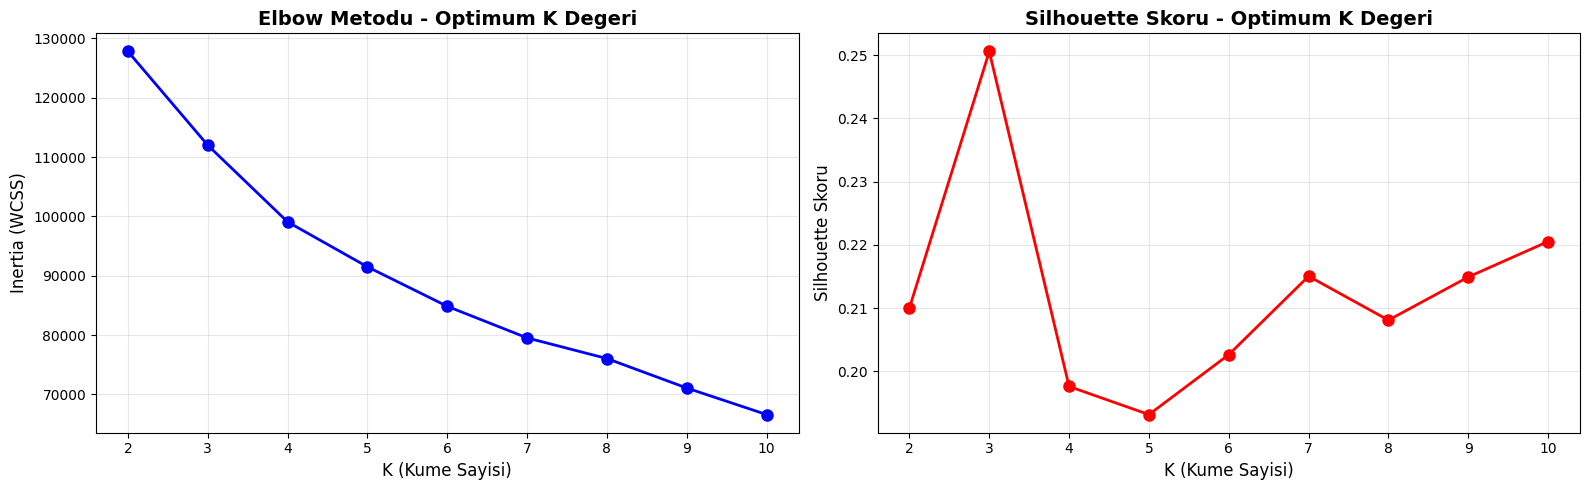

En iyi silhoutte skoru: 0.2506
Optimum K degeri: 3


In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Gorsellestirme
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Metodu - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[0].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Skoru - Optimum K Degeri', fontsize=14, fontweight='bold')
axes[1].set_xlabel('K (Kume Sayisi)', fontsize=12)
axes[1].set_ylabel('Silhouette Skoru', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'En iyi silhoutte skoru: {max(silhouette_scores):.4f}')
print(f'Optimum K degeri: {optimal_k}')

In [ ]:
optimal_k = 3  # Elbow ve silhouette analizine gore
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print('K-Means Kumeleme Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, kmeans_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, kmeans_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, kmeans_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means Kumeleme Sonuclari:
Kume sayisi: 3
Silhouette Skoru: 0.2506
Davies-Bouldin Indeksi: 1.5973
Calinski-Harabasz Skoru: 1604.3967

Kume dagilimi:
0    1596
1    1235
2    6119
Name: count, dtype: int64


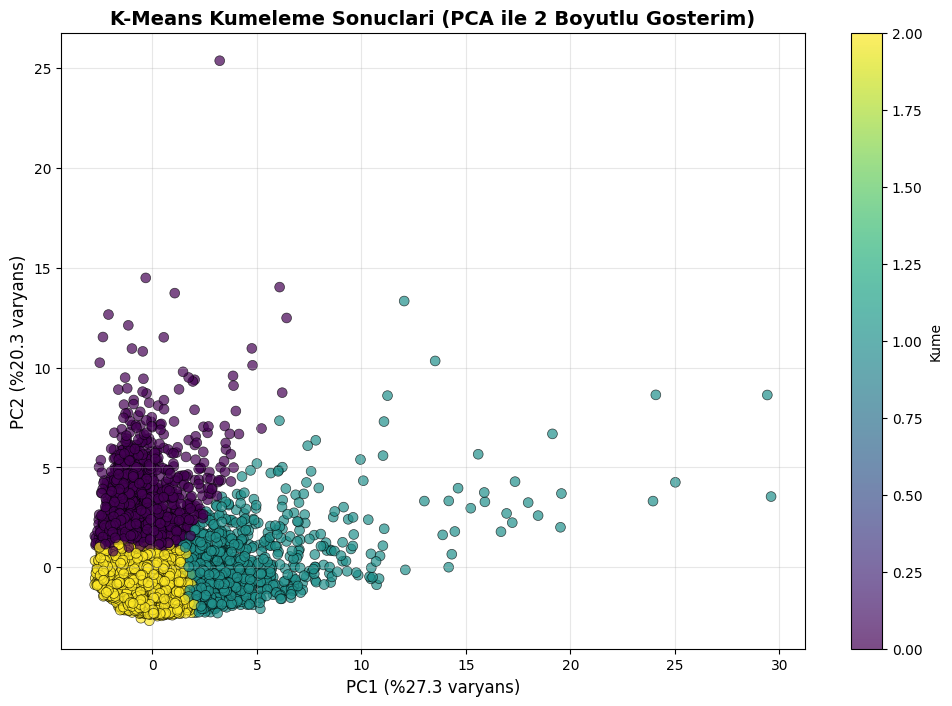

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis',
                      alpha=0.7, s=50, edgecolors='k', linewidth=0.5)
plt.colorbar(scatter, label='Kume')
plt.title('K-Means Kumeleme Sonuclari (PCA ile 2 Boyutlu Gosterim)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 (%{pca.explained_variance_ratio_[0]*100:.1f} varyans)', fontsize=12)
plt.ylabel(f'PC2 (%{pca.explained_variance_ratio_[1]*100:.1f} varyans)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

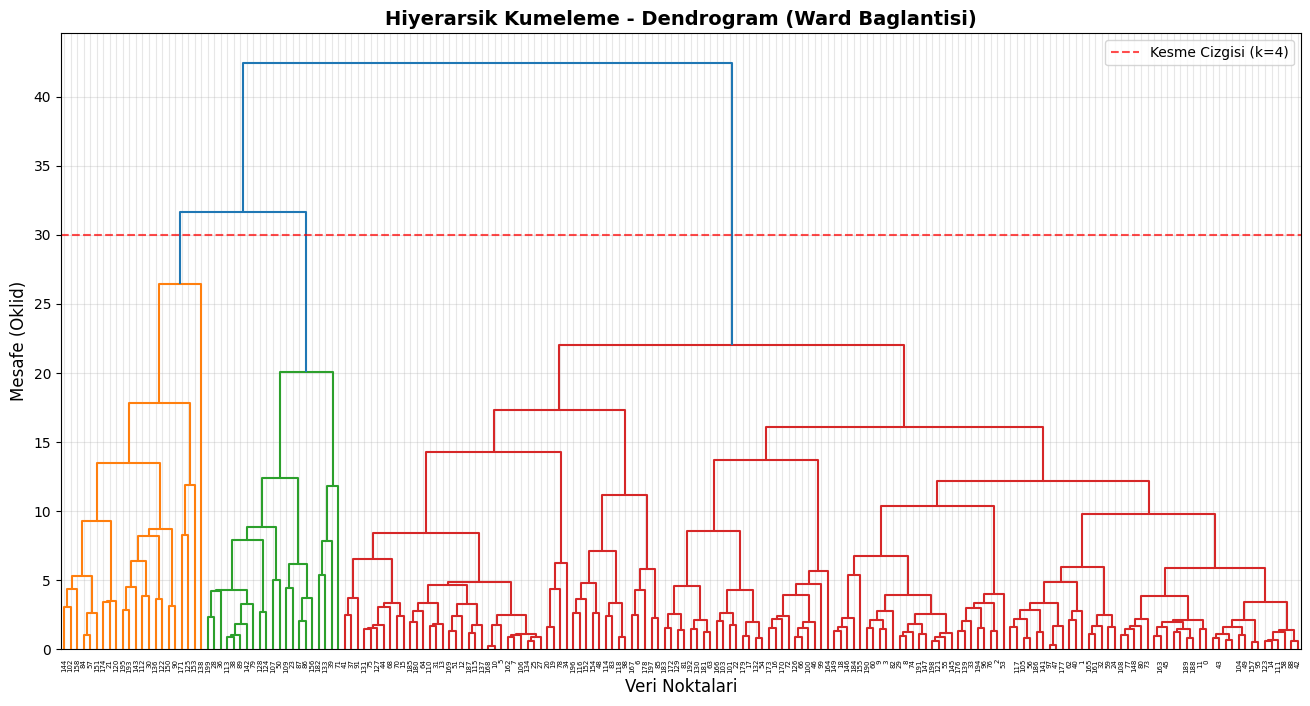

In [ ]:
plt.figure(figsize=(16, 8))
linked = linkage(X_scaled[:200], method='ward')  # Gorsellestirme icin 200 ornek
dendrogram(linked, orientation='top', distance_sort='descending',
           show_leaf_counts=False, truncate_mode='level', p=10)
plt.title('Hiyerarsik Kumeleme - Dendrogram (Ward Baglantisi)', fontsize=14, fontweight='bold')
plt.xlabel('Veri Noktalari', fontsize=12)
plt.ylabel('Mesafe (Oklid)', fontsize=12)
plt.axhline(y=30, color='r', linestyle='--', alpha=0.7, label='Kesme Cizgisi (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
agg_clustering = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

print('Hiyerarsik Kumeleme (Agglomerative) Sonuclari:')
print(f'Kume sayisi: {optimal_k}')
print(f'Baglanti yontemi: ward')
print(f'Silhouette Skoru: {silhouette_score(X_scaled, agg_labels):.4f}')
print(f'Davies-Bouldin Indeksi: {davies_bouldin_score(X_scaled, agg_labels):.4f}')
print(f'Calinski-Harabasz Skoru: {calinski_harabasz_score(X_scaled, agg_labels):.4f}')
print(f'\nKume dagilimi:')
print(pd.Series(agg_labels).value_counts().sort_index())

Hiyerarsik Kumeleme (Agglomerative) Sonuclari:
Kume sayisi: 3
Baglanti yontemi: ward
Silhouette Skoru: 0.1731
Davies-Bouldin Indeksi: 1.7979
Calinski-Harabasz Skoru: 1270.5039

Kume dagilimi:
0    3418
1    4668
2     864
Name: count, dtype: int64
